In [1]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn.objects as so

import os
import sys

sys.path.insert(0, r"C:\ProjectsDannyDavis\VolatilityPredictionProject\utils")

import API_Keys
from File_Paths import raw_data_filepath
import OpenBBConvenienceFunctions as obb_cf
import PlottingFunctions as plot_func
from file_reader import read_file

import pmdarima as pm
from statsmodels.stats.diagnostic import het_arch

In [2]:
SAP = read_file(raw_data_filepath, r"SP500_price_data.parquet")
var_df = pd.DataFrame(SAP['simple_return']**2)

#### ARIMA Model

c:\ProjectsDannyDavis\DDVenv\Lib\site-packages\pmdarima\utils\visualization.py:220: FutureWarning: the 'unbiased' keyword is deprecated, use 'adjusted' instead.
  res = tsaplots.plot_acf(


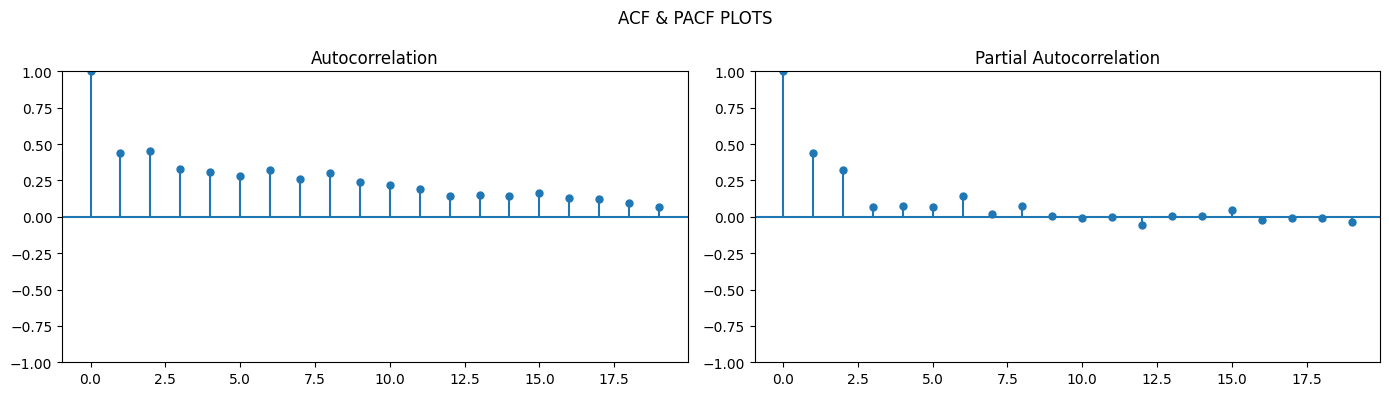

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

pm.plot_acf(var_df, lags=np.arange(20), ax=ax[0], show=False)
pm.plot_pacf(var_df.squeeze(), lags=np.arange(20), ax=ax[1], show=False)

fig.suptitle('ACF & PACF PLOTS')
plt.tight_layout()
plt.show();

In [4]:
grid_search = pm.auto_arima(y=var_df,
                            start_p=1,
                            max_p=10,
                            d=0,
                            start_q=1,
                            max_q=10,
                            seasonal=False,
                            information_criterion='bic',
                            stepwise=True)

In [5]:
# ARIMA order

grid_search.order

(1, 0, 3)

In [6]:
grid_search.pvalues()

ar.L1      0.000000e+00
ma.L1      0.000000e+00
ma.L2     2.281958e-127
ma.L3      0.000000e+00
sigma2     0.000000e+00
dtype: float64

In [7]:
grid_search.arima_res_.model_orders

{'trend': 0,
 'exog': 0,
 'ar': 1,
 'ma': 3,
 'seasonal_ar': 0,
 'seasonal_ma': 0,
 'reduced_ar': 1,
 'reduced_ma': 3,
 'exog_variance': 0,
 'measurement_variance': 0,
 'variance': 1}

In [8]:
print(grid_search.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 4023
Model:               SARIMAX(1, 0, 3)   Log Likelihood               25919.973
Date:                Sun, 17 May 2026   AIC                         -51829.947
Time:                        17:33:34   BIC                         -51798.448
Sample:                             0   HQIC                        -51818.784
                               - 4023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9448      0.002    547.575      0.000       0.941       0.948
ma.L1         -0.6888      0.003   -218.728      0.000      -0.695      -0.683
ma.L2          0.0795      0.003     24.008      0.0

In [9]:
grid_search.arroots()

array([1.05840753])

In [10]:
grid_search.maroots()

array([ 1.23933989-0.j        , -0.33788156-2.36785728j,
       -0.33788156+2.36785728j])

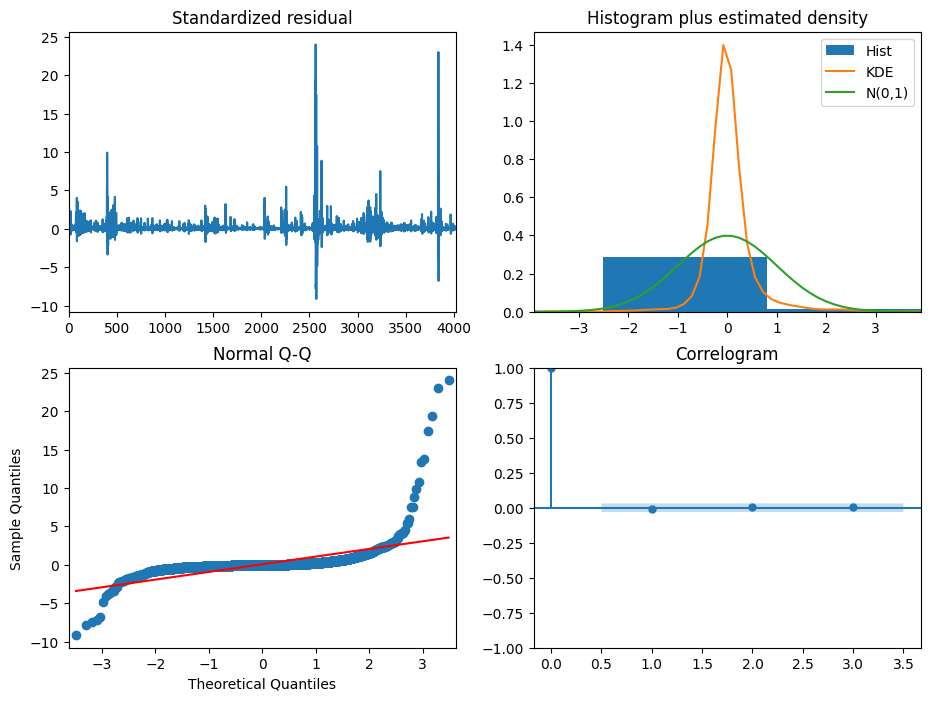

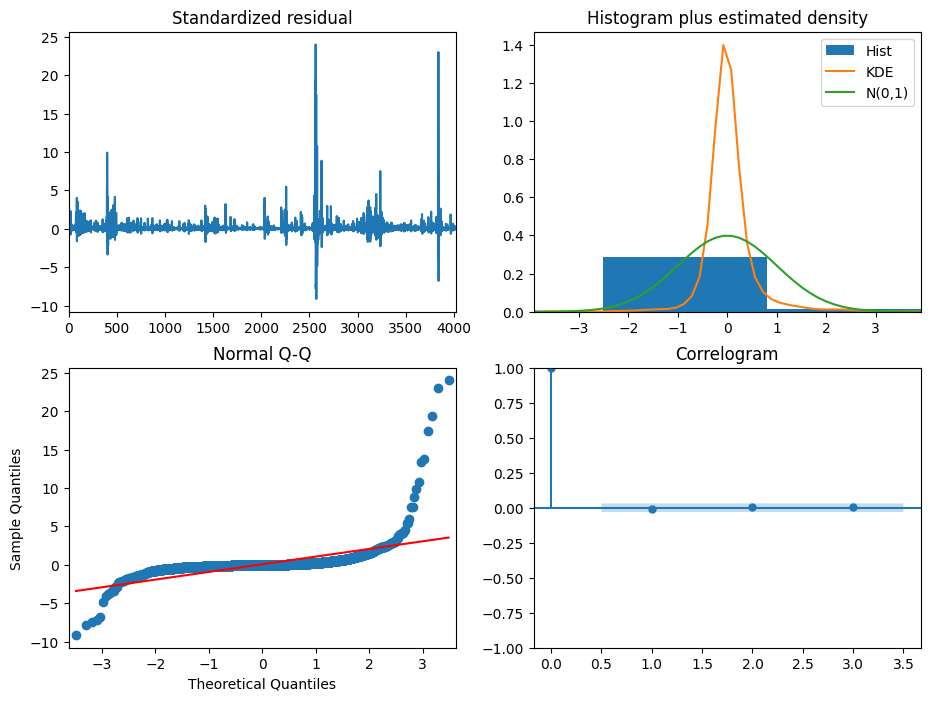

In [41]:
grid_search.plot_diagnostics(figsize=(11,8), lags=3)

### Engle's ARCH-LM test

In [11]:
residuals = grid_search.resid()

In [12]:
degs = grid_search.df_model()

In [13]:
arch_lm_test = het_arch(resid=residuals, nlags=5, ddof=degs, store=True)

In [14]:
print("RESULTS")
print("==========")
print(f"Lagrange Multiplier: {arch_lm_test[0].round(2)}")
print(f"Lagrange P-value: {arch_lm_test[1].round(2)}")
print(f"F-Stat: {round(arch_lm_test[2],2)}")
print(f"F-Stat P-value: {round(arch_lm_test[3],2)}")

RESULTS
Lagrange Multiplier: 589.7
Lagrange P-value: 0.0
F-Stat: 138.22
F-Stat P-value: 0.0


In [15]:
print(arch_lm_test[-1].resols.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.146
Method:                 Least Squares   F-statistic:                     138.2
Date:                Sun, 17 May 2026   Prob (F-statistic):          1.32e-135
Time:                        17:34:01   Log-Likelihood:                 46772.
No. Observations:                4018   AIC:                        -9.353e+04
Df Residuals:                    4012   BIC:                        -9.350e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.875e-08   3.38e-08      2.035      0.0

### Visuals

In [16]:
fitted_values = pd.DataFrame(grid_search.fittedvalues())
residuals = pd.DataFrame(grid_search.resid())
originals = var_df.copy()

In [17]:
fitted_values.columns = ['fitted_arma']
residuals.columns = ['residuals_arma']
originals.columns = ['realised_vol']

In [18]:
combined_df = originals.merge(fitted_values, 
                              left_index=True, 
                              right_index=True, 
                              how='inner').merge(residuals, 
                                                 left_index=True, 
                                                 right_index=True, 
                                                 how='inner')

In [19]:
combined_df.index = pd.to_datetime(combined_df.index)

In [22]:
from PlottingFunctions import TEAL_SEQUENCE
import matplotlib.dates as mdates

plot_data = combined_df.loc['2018':].copy()
plot_data['squared_residuals'] = plot_data['residuals_arma'] ** 2

vol_clip   = plot_data['realised_vol'].quantile(0.995)
resid_clip = plot_data['squared_residuals'].quantile(0.995)
dates = plot_data.index

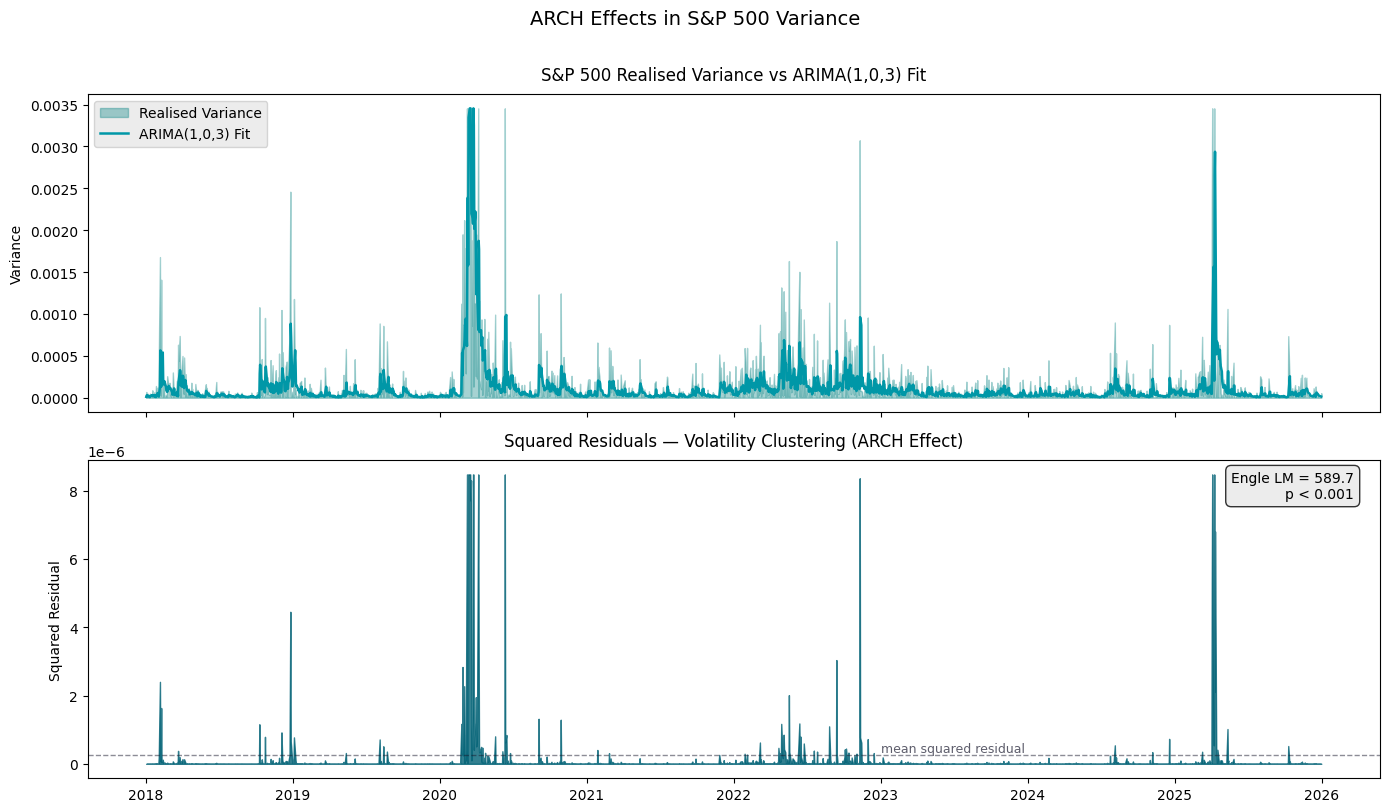

In [34]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel 1: Realised variance vs ARIMA fit
ax1.fill_between(dates, plot_data['realised_vol'].clip(upper=vol_clip),
                 color=TEAL_SEQUENCE[2], alpha=0.35, label='Realised Variance')
ax1.plot(dates, plot_data['fitted_arma'].clip(upper=vol_clip),
         color='#0097A7', linewidth=1.8, label='ARIMA(1,0,3) Fit')
ax1.set_title('S&P 500 Realised Variance vs ARIMA(1,0,3) Fit', pad=10)
ax1.set_ylabel('Variance')
legend = ax1.legend(loc='upper left')
legend.get_frame().set_facecolor('#e8e8e8')

# Panel 2: Squared residuals — clustering is the ARCH story
mean_resid = plot_data['squared_residuals'].mean()
# ax2.set_facecolor('#f2f2f2')
ax2.fill_between(dates, plot_data['squared_residuals'].clip(upper=resid_clip),
                 color=TEAL_SEQUENCE[1], alpha=0.8, label='Squared Residuals')
ax2.axhline(mean_resid, color='#1a1a2e', linestyle='--', linewidth=1, alpha=0.5)
ax2.text(pd.Timestamp('2023-01-01'), mean_resid, 'mean squared residual',
         va='bottom', fontsize=9, color='#1a1a2e', alpha=0.7)
ax2.set_title('Squared Residuals — Volatility Clustering (ARCH Effect)', pad=10)
ax2.set_ylabel('Squared Residual')
ax2.annotate('Engle LM = 589.7\np < 0.001',
             xy=(0.98, 0.88), xycoords='axes fraction',
             ha='right', fontsize=10,
             bbox=dict(boxstyle='round,pad=0.4', facecolor='#e8e8e8', alpha=0.8))

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator())

plt.suptitle('ARCH Effects in S&P 500 Variance', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()